In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [10]:
#Dataset Creation
dataset = pd.read_csv('Telco-Customer-Churn.csv')
print(dataset.head(10))

print(dataset.isnull().sum())
print(dataset.describe())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

In [11]:
print(dataset.isnull().sum())
print(dataset.describe())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [12]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')
dataset['TotalCharges'].fillna(dataset['TotalCharges'].median(), inplace=True)

C:\Users\syeda\AppData\Local\Temp\ipykernel_19760\266048525.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['TotalCharges'].fillna(dataset['TotalCharges'].median(), inplace=True)


In [23]:
#Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

labelencoder = LabelEncoder()
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
                    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
for col in categorical_cols:
    dataset[col] = labelencoder.fit_transform(dataset[col])

X = dataset[['tenure',
'MonthlyCharges',
'TotalCharges',
'SeniorCitizen']]
y = dataset['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [24]:
#Training
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# ============================================================
# 5. BUILD ANN
# ============================================================

model = Sequential([
    
    # Input + Hidden Layer 1
    Dense(8, activation="relu", input_shape=(4,)),
    
    # Hidden Layer 2
    Dense(4, activation="relu"),
    
    # Output Layer
    Dense(1, activation="sigmoid")
])
# ============================================================
# 6. COMPILE MODEL
# ============================================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
# ============================================================
# 7. TRAIN ANN
# ============================================================

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
# ============================================================
# 8. TRAINING ACCURACY
# ============================================================

train_loss, train_accuracy = model.evaluate(
    X_train,
    y_train,
    verbose=0
)

print("\n===================================")
print("TRAINING RESULTS")
print("===================================")

print("Training Loss    :", train_loss)
print("Training Accuracy:", train_accuracy * 100, "%")

# ============================================================
# 9. TESTING ACCURACY
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n===================================")
print("TESTING RESULTS")
print("===================================")

print("Testing Loss     :", test_loss)
print("Testing Accuracy :", test_accuracy * 100, "%")



Epoch 1/50


C:\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6863 - loss: 0.6257 - val_accuracy: 0.7524 - val_loss: 0.5318
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7289 - loss: 0.5345 - val_accuracy: 0.7524 - val_loss: 0.4771
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7289 - loss: 0.5009 - val_accuracy: 0.7524 - val_loss: 0.4543
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7289 - loss: 0.4855 - val_accuracy: 0.7524 - val_loss: 0.4445
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7289 - loss: 0.4787 - val_accuracy: 0.7524 - val_loss: 0.4401
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7420 - loss: 0.4745 - val_accuracy: 0.7746 - val_loss: 0.4376
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7719 - loss: 0.4712 - val_accuracy: 0.8030 - val_loss: 0.4360
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7832 - loss: 0.4689 - val_accuracy: 0.8137 - val_

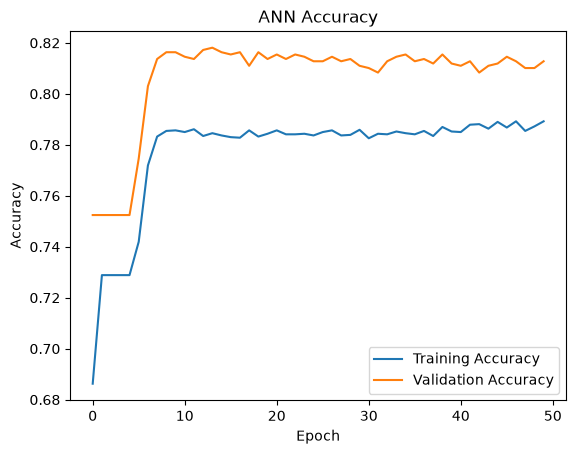

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Accuracy")
plt.legend()
plt.show()

In [26]:
print("\n===================================")
print("CUSTOMER CHURN PREDICTOR")
print("===================================")

tenure = float(input("Enter Tenure (months): "))
monthly_charges = float(input("Enter Monthly Charges: "))
total_charges = float(input("Enter Total Charges: "))
senior_citizen = int(input("Senior Citizen? (0 = No, 1 = Yes): "))

new_customer = pd.DataFrame({
    "tenure": [tenure],
    "MonthlyCharges": [monthly_charges],
    "TotalCharges": [total_charges],
    "SeniorCitizen": [senior_citizen]
})

# Scale using the TRAINING scaler
new_customer_scaled = scaler.transform(new_customer)

# Prediction
probability = model.predict(
    new_customer_scaled,
    verbose=0
)[0][0]

prediction = int(probability >= 0.5)

print("\n===================================")
print("PREDICTION")
print("===================================")

print(f"Churn Probability : {probability * 100:.2f}%")
print(f"Predicted Class   : {prediction}")

if prediction == 1:
    print("Customer is likely to CHURN")
else:
    print("Customer is likely to STAY")


CUSTOMER CHURN PREDICTOR


Enter Tenure (months):  8
Enter Monthly Charges:  120
Enter Total Charges:  960
Senior Citizen? (0 = No, 1 = Yes):  0



PREDICTION
Churn Probability : 65.88%
Predicted Class   : 1
Customer is likely to CHURN


In [27]:
import joblib

# Save ANN
model.save("model.keras")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
